In [130]:
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr
import pandas as pd
from scipy import signal
from osgeo import gdal
import matplotlib.dates as mdates
from scipy import stats

# Setting parameters for the figures produced
plt.rcParams['font.sans-serif'] = 'Arial' 
plt.rcParams['font.size'] = 12 
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial'
plt.rcParams['figure.facecolor'] = 'white' 
plt.rcParams['figure.dpi'] = 100

In [131]:
def get_powerlaw_constants(x,y):
    # Assumes a model y= l * x**n
    # l is the prefactor, n is the exponent (slope in log scale)
    # take log of x and y and fit a straight line 
    polyfit = np.polyfit(np.log10(x),np.log10(y),1)
    # recover the constants 
    l,n = 10**polyfit[1],polyfit[0]
    return l,n

def xyz_geotiff(img):
    band = img.GetRasterBand(1)
    z = np.flipud(band.ReadAsArray()).T
    width = img.RasterXSize
    height = img.RasterYSize
    gt = img.GetGeoTransform()
    minx = gt[0]
    miny = gt[3] + width*gt[4] + height*gt[5]
    maxx = gt[0] + width*gt[1] + height*gt[2]
    maxy = gt[3]
    lon = np.linspace(minx,maxx,width)
    lat = np.linspace(miny,maxy,height)
    return lon,lat,z

def get_autocorrelation(x,y,z,edgewidth):
    pad  = np.pad(np.ones((np.shape(z)[0]-2*edgewidth,np.shape(z)[1]-2*edgewidth)),
                  (edgewidth,edgewidth),
                  mode='constant',constant_values=0)
    zn   = (z-np.mean(z))/np.std(z)
    zfft = np.fft.fft2(zn)
    zc   = np.fft.fftshift(np.fft.ifft2((zfft*pad)*np.conj((zfft*pad)))).real
    zc  /= np.max(zc)
    xc   = x-np.mean(x)
    yc   = y-np.mean(y)
    return xc,yc,zc

def get_angle_spacing(xc,yc,zc):
    idx_min = np.argwhere(zc==np.min(zc))[0]
    x_min = xc[idx_min[1]]
    y_min = yc[idx_min[0]]
    angle   = np.arctan2(y_min,x_min)
    spacing = ((x_min*2)**2+(y_min*2)**2)**0.5
    return angle,spacing


Mt Buller Max and Min Temperature data and code 

In [132]:
# Reading in the data 
Mon_max = pd.read_csv('Monthly_max.csv')
Mon_min = pd.read_csv('Monthly_min.csv')

In [133]:
# Recreating the date data from the data set into a new datetime column so it can be plotted 
Mon_max['date'] = pd.to_datetime(Mon_max[['Year', 'Month']].assign(Day=1))
Mon_min['date'] = pd.to_datetime(Mon_min[['Year', 'Month']].assign(Day=1))

In [134]:
# Filtering to ski season months (June to October)
Mon_max_winter = Mon_max[Mon_max['Month'].isin([6, 7, 8, 9, 10])].copy()
Mon_min_winter = Mon_min[Mon_min['Month'].isin([6, 7, 8, 9, 10])].copy()

# Recreating the date column on the filtered data created above so it can be plotted
Mon_max_winter['date'] = pd.to_datetime(Mon_max_winter[['Year', 'Month']].assign(Day=1))
Mon_min_winter['date'] = pd.to_datetime(Mon_min_winter[['Year', 'Month']].assign(Day=1))

# Ordinal conversion
x_max = Mon_max_winter['date'].map(pd.Timestamp.toordinal)
x_min = Mon_min_winter['date'].map(pd.Timestamp.toordinal)

# Calculating the regression
slope_max, intercept_max, r_max, p_max, se_max = stats.linregress(x_max, Mon_max_winter['max_t_(C)'])
slope_min, intercept_min, r_min, p_min, se_min = stats.linregress(x_min, Mon_min_winter['min_t_(C)'])

slope_max_decade = slope_max * 365.25 * 10
slope_min_decade = slope_min * 365.25 * 10

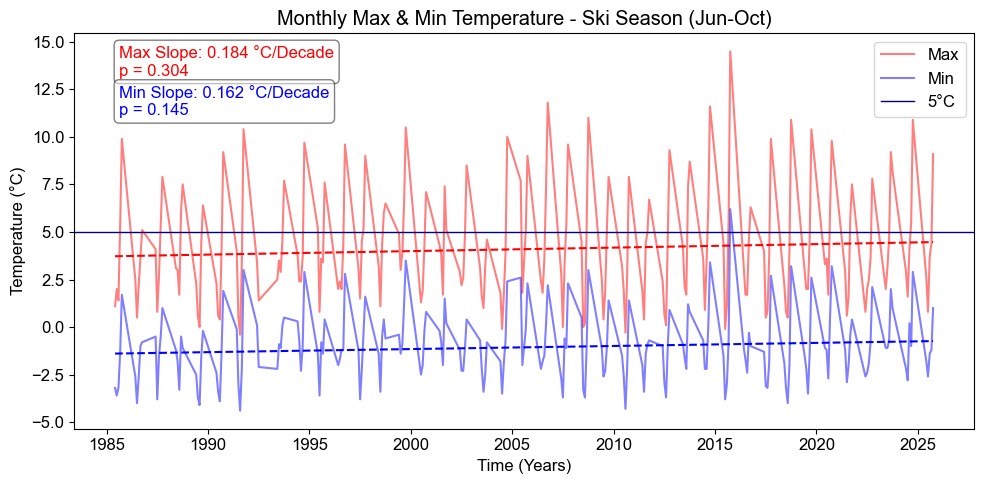

In [135]:
plt.figure(figsize=(10, 5))

# Max temp
plt.plot(Mon_max_winter['date'], Mon_max_winter['max_t_(C)'], label='Max', color='red', alpha=0.5)
plt.plot(Mon_max_winter['date'], slope_max * x_max + intercept_max, '--', color='red')

# Min temp
plt.plot(Mon_min_winter['date'], Mon_min_winter['min_t_(C)'], label='Min', color='blue', alpha=0.5)
plt.plot(Mon_min_winter['date'], slope_min * x_min + intercept_min, '--', color='blue')

# Adding a horizontal line at 5 degrees (the temp limit for snowmaking)
plt.axhline(y=5, color='navy', linestyle='-', linewidth=1, label='5°C')

# Annotations
plt.annotate(f'Max Slope: {slope_max_decade:.3f} °C/Decade\np = {p_max:.3f}',
            xy=(0.05, 0.97), xycoords='axes fraction', fontsize=12,
            verticalalignment='top', color='red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.annotate(f'Min Slope: {slope_min_decade:.3f} °C/Decade\np = {p_min:.3f}',
            xy=(0.05, 0.87), xycoords='axes fraction', fontsize=12,
            verticalalignment='top', color='blue',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.ylabel('Temperature (°C)')
plt.xlabel('Time (Years)')
plt.title('Monthly Max & Min Temperature - Ski Season (Jun-Oct)')
plt.legend()
plt.tight_layout()
#plt.savefig("/Users/declanobrien/Documents/2026/MMT.pdf", bbox_inches="tight")
plt.show()

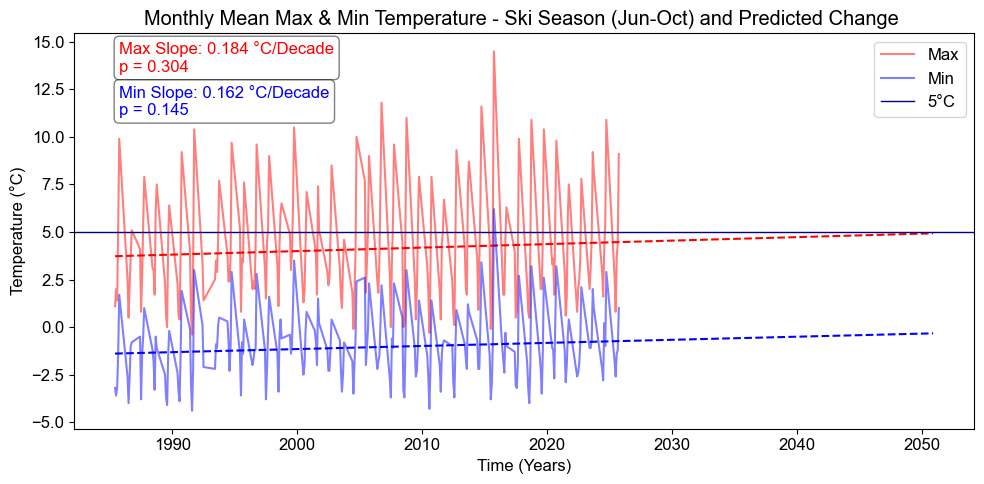

In [136]:
plt.figure(figsize=(10, 5))

# Creating extended dates to 2050 and converting to ordinal to match the  x_max and x_min
future_dates = pd.date_range(start=Mon_max_winter['date'].min(), end='2050-12-31', freq='MS')
future_x = np.array([pd.Timestamp(d).toordinal() for d in future_dates])

# Max temp - original data
plt.plot(Mon_max_winter['date'], Mon_max_winter['max_t_(C)'], label='Max', color='red', alpha=0.5)
# Max temp - extended to 2050
plt.plot(future_dates, slope_max * future_x + intercept_max, '--', color='red')

# Min temp - original data
plt.plot(Mon_min_winter['date'], Mon_min_winter['min_t_(C)'], label='Min', color='blue', alpha=0.5)
# Min temp - extended to 2050
plt.plot(future_dates, slope_min * future_x + intercept_min, '--', color='blue')

# Adding a horizontal line at 5 degrees (the temp limit for snowmaking)
plt.axhline(y=5, color='navy', linestyle='-', linewidth=1, label='5°C')

# Annotations
plt.annotate(f'Max Slope: {slope_max_decade:.3f} °C/Decade\np = {p_max:.3f}',
            xy=(0.05, 0.98), xycoords='axes fraction', fontsize=12,
            verticalalignment='top', color='red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.annotate(f'Min Slope: {slope_min_decade:.3f} °C/Decade\np = {p_min:.3f}',
            xy=(0.05, 0.87), xycoords='axes fraction', fontsize=12,
            verticalalignment='top', color='blue',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.ylabel('Temperature (°C)')
plt.xlabel('Time (Years)')
plt.title('Monthly Mean Max & Min Temperature - Ski Season (Jun-Oct) and Predicted Change ')
plt.legend()
plt.tight_layout()
#plt.savefig("/Users/declanobrien/Documents/2026/MMT.pdf", bbox_inches="tight")
plt.show()

Mt Buller natural snow depth and snowmaking snow depth 

In [137]:
Mt_Buller_data  = pd.read_csv('MtBuller_Snow.csv')
#data available at https://discover.data.vic.gov.au/dataset/victorian-alpine-resorts-daily-snow-depth-records-mount-buller
mats = np.unique(Mt_Buller_data['Depth_type'].dropna().unique())
print(mats)

['Natural' 'Snow-making Average']


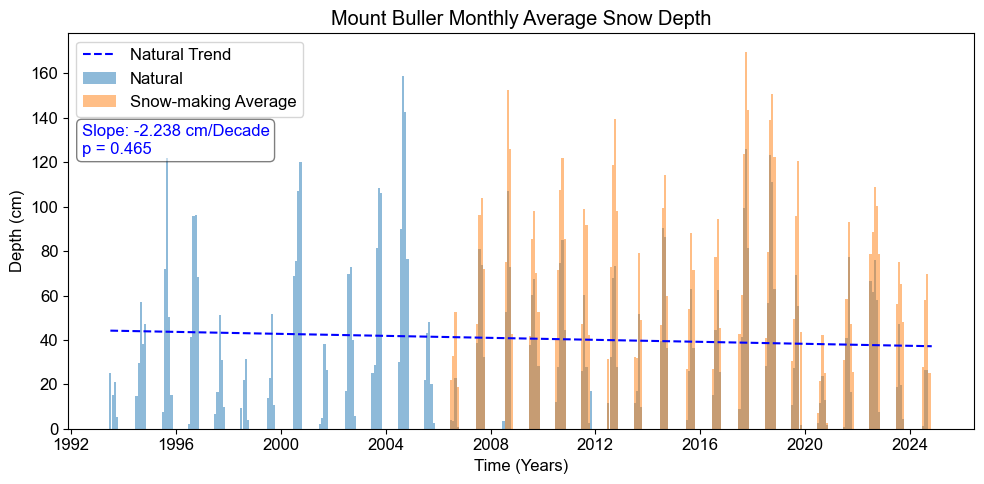

In [138]:
# converting the date from strings to datetime objects
Mt_Buller_data['Date'] = pd.to_datetime(Mt_Buller_data['Date'], dayfirst=True)
# removing + signs from the snow depth data
Mt_Buller_data['Depth_(cm)'] = Mt_Buller_data['Depth_(cm)'].astype(str).str.replace('+', '', regex=False)
# converting the depths from strings to numbers
Mt_Buller_data['Depth_(cm)'] = pd.to_numeric(Mt_Buller_data['Depth_(cm)'], errors='coerce')

# Resampling to yearly averages
Mt_Buller_yearly = Mt_Buller_data.groupby(['Depth_type', pd.Grouper(key='Date', freq='ME')])['Depth_(cm)'].mean().reset_index()

# Filtering natural data for trendline
natural = Mt_Buller_yearly[Mt_Buller_yearly['Depth_type'] == 'Natural'].dropna()
x_nat = natural['Date'].map(pd.Timestamp.toordinal)
y_nat = natural['Depth_(cm)']

# Calculating the regression
slope, intercept, r, p, se = stats.linregress(x_nat, y_nat)
slope_decade = slope * 365.25 * 10

plt.figure(figsize=(10, 5))
mats_buller = Mt_Buller_data['Depth_type'].dropna().unique()

for i in range(len(mats_buller)):
    x = Mt_Buller_yearly[Mt_Buller_yearly['Depth_type'] == mats_buller[i]]['Date']
    y = Mt_Buller_yearly[Mt_Buller_yearly['Depth_type'] == mats_buller[i]]['Depth_(cm)']
    plt.bar(x, y, label=mats_buller[i], alpha=0.5, width=30)

# Making the trendline for natural snow depth
plt.plot(natural['Date'], slope * x_nat + intercept, '--', color='blue', label='Natural Trend')
plt.annotate(f'Slope: {slope_decade:.3f} cm/Decade\np = {p:.3f}',
            xy=(0.015, 0.77), xycoords='axes fraction', fontsize=12,
            verticalalignment='top', color='blue',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.xlabel('Time (Years)')
plt.ylabel('Depth (cm)')
plt.title('Mount Buller Monthly Average Snow Depth')
plt.legend()
plt.tight_layout()
#plt.savefig("/Users/declanobrien/Documents/2026/BullerMSD.pdf", bbox_inches="tight")
plt.show()

Creating subplots of snow depth and temperature data 

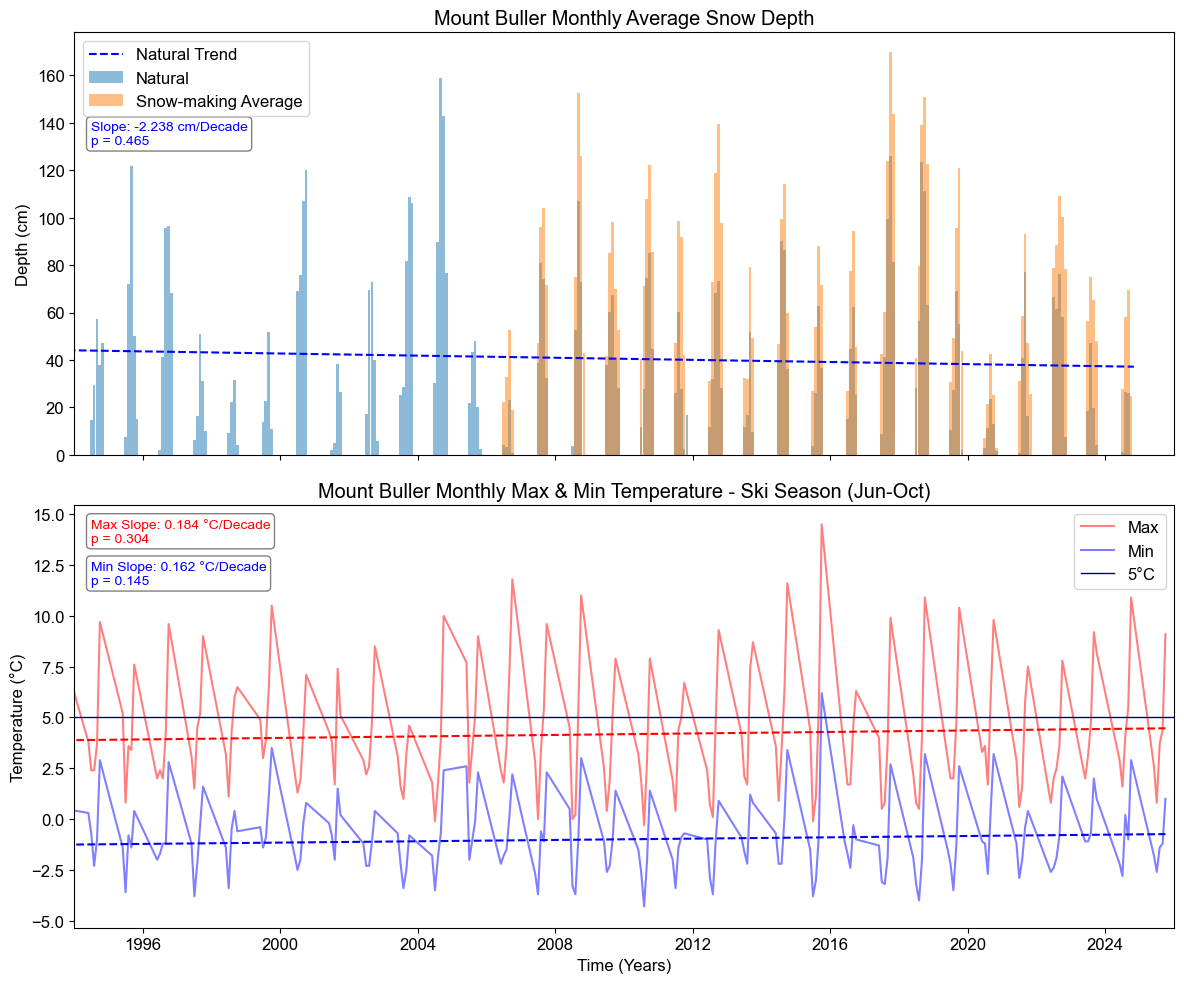

In [139]:
# Recomputing x arrays from the correct dataframes
x_max = mdates.date2num(Mon_max_winter['date'])
slope_max, intercept_max = np.polyfit(x_max, Mon_max_winter['max_t_(C)'], 1)

x_min = mdates.date2num(Mon_min_winter['date'])
slope_min, intercept_min = np.polyfit(x_min, Mon_min_winter['min_t_(C)'], 1)

# Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Snow Depth subplot
mats_buller = Mt_Buller_data['Depth_type'].dropna().unique()
for i in range(len(mats_buller)):
    x = Mt_Buller_yearly[Mt_Buller_yearly['Depth_type'] == mats_buller[i]]['Date']
    y = Mt_Buller_yearly[Mt_Buller_yearly['Depth_type'] == mats_buller[i]]['Depth_(cm)']
    ax1.bar(x, y, label=mats_buller[i], alpha=0.5, width=30)
ax1.plot(natural['Date'], slope * x_nat + intercept, '--', color='blue', label='Natural Trend')
ax1.annotate(f'Slope: {slope_decade:.3f} cm/Decade\np = {p:.3f}',
            xy=(0.015, 0.79), xycoords='axes fraction', fontsize=10,
            verticalalignment='top', color='blue',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax1.legend(loc='upper left')
ax1.set_ylabel('Depth (cm)')
ax1.set_title('Mount Buller Monthly Average Snow Depth')

# Temperature subplot 
ax2.plot(Mon_max_winter['date'], Mon_max_winter['max_t_(C)'], label='Max', color='red', alpha=0.5)
ax2.plot(Mon_max_winter['date'], slope_max * x_max + intercept_max, '--', color='red')
ax2.plot(Mon_min_winter['date'], Mon_min_winter['min_t_(C)'], label='Min', color='blue', alpha=0.5)
ax2.plot(Mon_min_winter['date'], slope_min * x_min + intercept_min, '--', color='blue')
ax2.axhline(y=5, color='navy', linestyle='-', linewidth=1, label='5°C')
ax2.annotate(f'Max Slope: {slope_max_decade:.3f} °C/Decade\np = {p_max:.3f}',
            xy=(0.015, 0.97), xycoords='axes fraction', fontsize=10,
            verticalalignment='top', color='red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax2.annotate(f'Min Slope: {slope_min_decade:.3f} °C/Decade\np = {p_min:.3f}',
            xy=(0.015, 0.87), xycoords='axes fraction', fontsize=10,
            verticalalignment='top', color='blue',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax2.set_ylabel('Temperature (°C)')
ax2.set_xlabel('Time (Years)')
ax2.set_title('Mount Buller Monthly Max & Min Temperature - Ski Season (Jun-Oct)')
ax2.set_xlim(pd.Timestamp('1994-01-01'), pd.Timestamp('2025-12-31'))
ax2.legend()

plt.tight_layout()
#plt.savefig("/Users/declanobrien/Documents/2026/Combined.pdf", bbox_inches="tight")
plt.show()


Lake Mountian natural snow depth and snowmaking snow depth

In [140]:
Lake_Mt_data  = pd.read_csv('DSDR_LakeMt.csv')
# Data available at https://discover.data.vic.gov.au/dataset/victorian-alpine-resorts-daily-snow-depth-records-lake-mountain
mats = np.unique(Lake_Mt_data['Depth_type'].dropna().unique())
print(mats)

['Natural' 'Snow-making Average']


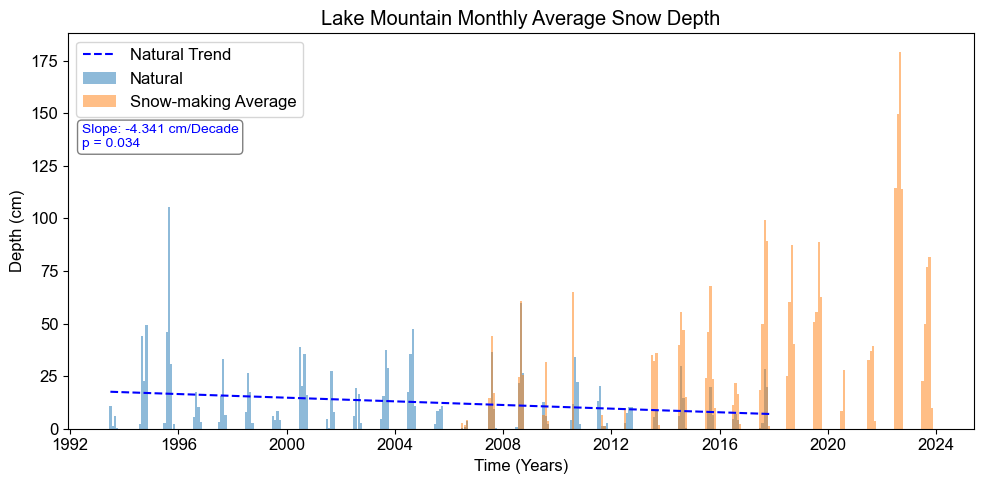

In [141]:
# Converting the date from strings to datetime objects
Lake_Mt_data['Date'] = pd.to_datetime(Lake_Mt_data['Date'], dayfirst=True)
# converting the depths from strings to numbers
Lake_Mt_data['Depth_(cm)'] = pd.to_numeric(Lake_Mt_data['Depth_(cm)'], errors='coerce')

# Resampling to make yearly averages
Lake_Mt_yearly = Lake_Mt_data.groupby(['Depth_type', pd.Grouper(key='Date', freq='ME')])['Depth_(cm)'].mean().reset_index()

# Filtering natural data for trendline
natural_lm = Lake_Mt_yearly[Lake_Mt_yearly['Depth_type'] == 'Natural'].dropna()
x_nat_lm = natural_lm['Date'].map(pd.Timestamp.toordinal)
y_nat_lm = natural_lm['Depth_(cm)']

# Calculating the regression line 
slope_lm, intercept_lm, r_lm, p_lm, se_lm = stats.linregress(x_nat_lm, y_nat_lm)
slope_decade_lm = slope_lm * 365.25 * 10

plt.figure(figsize=(10, 5))
mats_lm = Lake_Mt_data['Depth_type'].dropna().unique()

for i in range(len(mats_lm)):
    x = Lake_Mt_yearly[Lake_Mt_yearly['Depth_type'] == mats_lm[i]]['Date']
    y = Lake_Mt_yearly[Lake_Mt_yearly['Depth_type'] == mats_lm[i]]['Depth_(cm)']
    plt.bar(x, y, label=mats_lm[i], alpha=0.5, width=30)

# Trendline for natural
plt.plot(natural_lm['Date'], slope_lm * x_nat_lm + intercept_lm, '--', color='blue', label='Natural Trend')
plt.annotate(f'Slope: {slope_decade_lm:.3f} cm/Decade\np = {p_lm:.3f}',
            xy=(0.015, 0.77), xycoords='axes fraction', fontsize=10,
            verticalalignment='top', color='blue',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.xlabel('Time (Years)')
plt.ylabel('Depth (cm)')
plt.title('Lake Mountain Monthly Average Snow Depth')
plt.legend()
plt.tight_layout()
#plt.savefig("/Users/declanobrien/Documents/2026/LakeMtMSD.pdf", bbox_inches="tight")
plt.show()

Subplots of both Lake Mountian and Mt Buller natural snow depths and snowmaking snow depths 

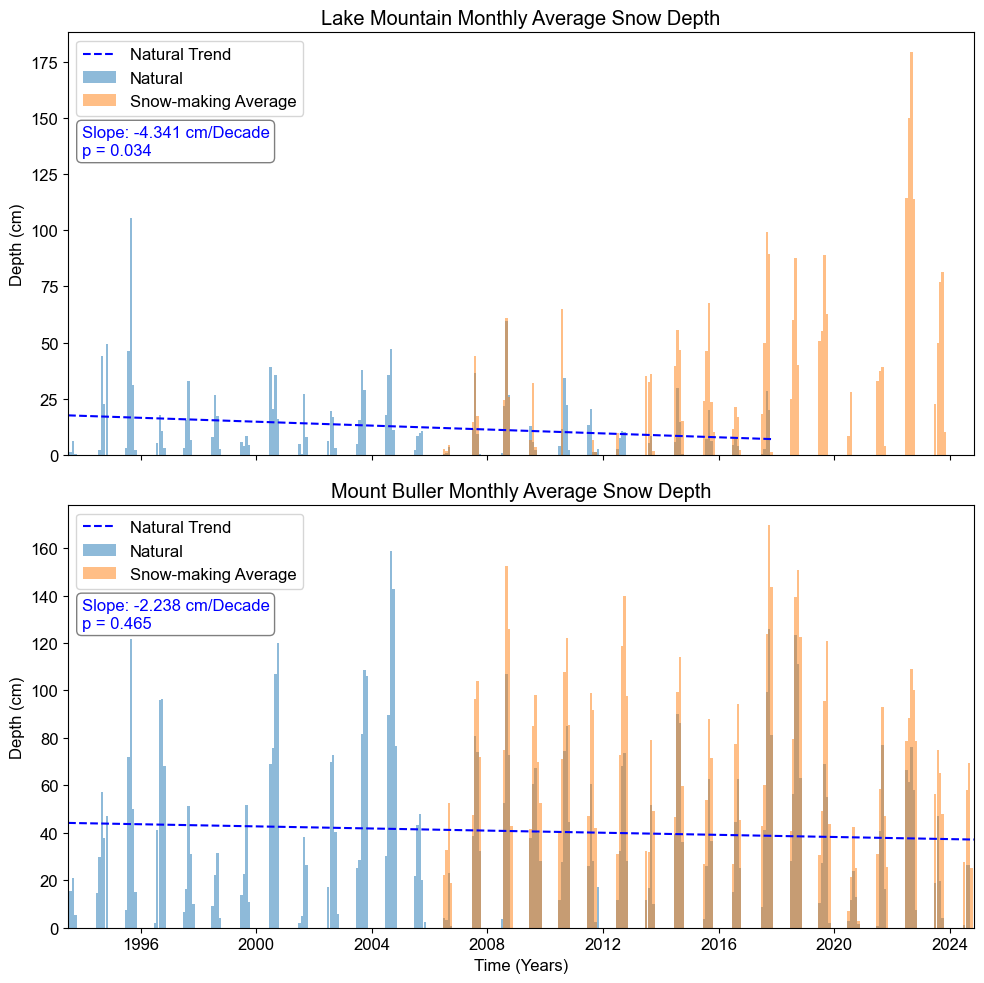

In [142]:
# Shared x-axis limits for the subplots 
all_dates = pd.concat([Lake_Mt_yearly['Date'], Mt_Buller_yearly['Date']])
x_min_date = all_dates.min()
x_max_date = all_dates.max()

# Subplots 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Top plot: Lake Mountain 
mats_lm = Lake_Mt_data['Depth_type'].dropna().unique()
for mat in mats_lm:
    x = Lake_Mt_yearly[Lake_Mt_yearly['Depth_type'] == mat]['Date']
    y = Lake_Mt_yearly[Lake_Mt_yearly['Depth_type'] == mat]['Depth_(cm)']
    ax1.bar(x, y, label=mat, alpha=0.5, width=30)
ax1.plot(natural_lm['Date'], slope_lm * x_nat_lm + intercept_lm, '--', color='blue', label='Natural Trend')
ax1.annotate(f'Slope: {slope_decade_lm:.3f} cm/Decade\np = {p_lm:.3f}',
             xy=(0.015, 0.78), xycoords='axes fraction', fontsize=12,
             verticalalignment='top', color='blue',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax1.set_ylabel('Depth (cm)')
ax1.set_title('Lake Mountain Monthly Average Snow Depth')
ax1.legend(loc='upper left')

# Bottom plot: Mt Buller 
mats_buller = Mt_Buller_data['Depth_type'].dropna().unique()
for mat in mats_buller:
    x = Mt_Buller_yearly[Mt_Buller_yearly['Depth_type'] == mat]['Date']
    y = Mt_Buller_yearly[Mt_Buller_yearly['Depth_type'] == mat]['Depth_(cm)']
    ax2.bar(x, y, label=mat, alpha=0.5, width=30)
ax2.plot(natural['Date'], slope * x_nat + intercept, '--', color='blue', label='Natural Trend')
ax2.annotate(f'Slope: {slope_decade:.3f} cm/Decade\np = {p:.3f}',
             xy=(0.015, 0.78), xycoords='axes fraction', fontsize=12,
             verticalalignment='top', color='blue',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax2.set_ylabel('Depth (cm)')
ax2.set_xlabel('Time (Years)')
ax2.set_title('Mount Buller Monthly Average Snow Depth')
ax2.legend(loc='upper left')

# Applying the shared x limits
ax1.set_xlim(x_min_date, x_max_date)

plt.tight_layout()
#plt.savefig("/Users/declanobrien/Documents/2026/SnowDepth_Combined.pdf", bbox_inches="tight")
plt.show()

Power spectra 

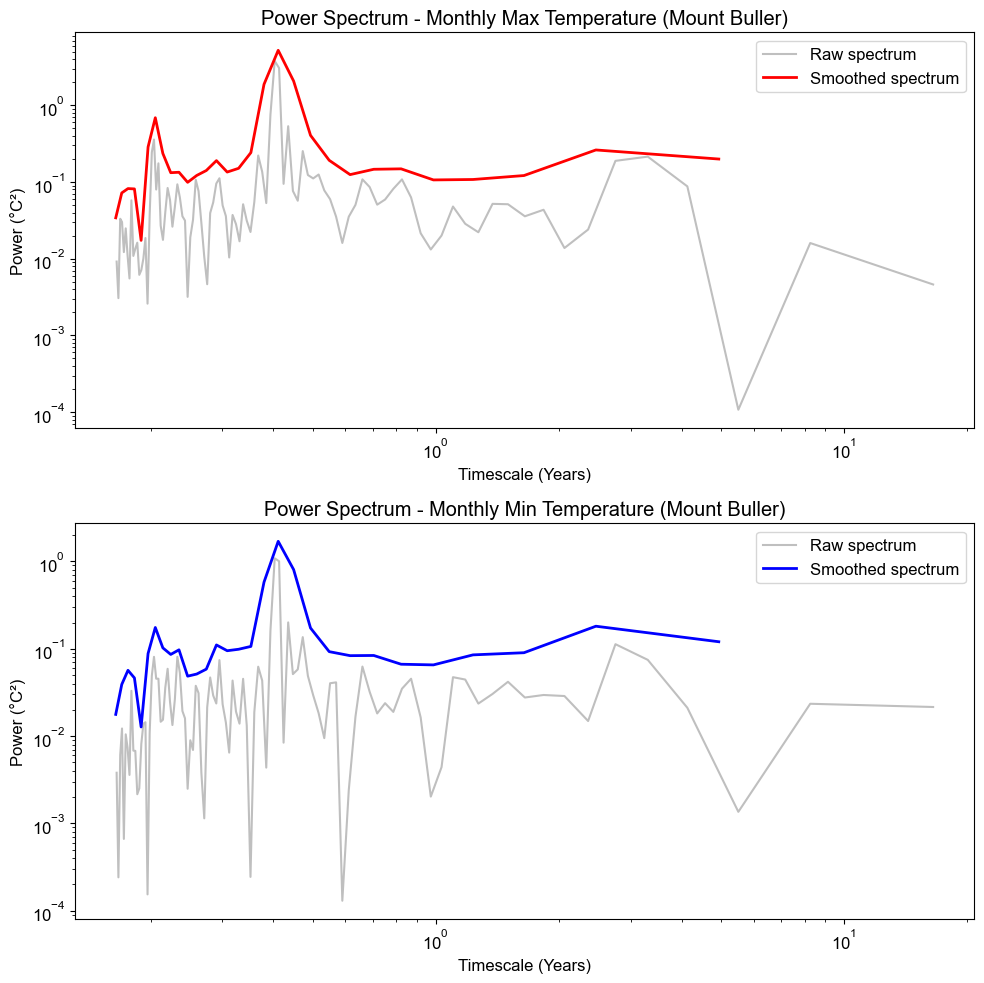

In [143]:
# Max temperature
date_max = Mon_max_winter['date'].values
max_t_ = Mon_max_winter['max_t_(C)'].values

# Min temperature
date_min = Mon_min_winter['date'].values
min_t_ = Mon_min_winter['min_t_(C)'].values

# Seconds to years conversion
s_to_yrs = 1 / (60*60*24*365)

# Welch for max
time_seconds_max = (date_max - np.min(date_max)) / np.timedelta64(1, 's')
f_max, PUU_max = signal.welch(max_t_, 1/np.diff(time_seconds_max)[0], nperseg=len(date_max), scaling='spectrum')
f_smooth_max, PUU_smooth_max = signal.welch(max_t_, 1/np.diff(time_seconds_max)[0], nperseg=60, scaling='spectrum')

# Welch for min
time_seconds_min = (date_min - np.min(date_min)) / np.timedelta64(1, 's')
f_min, PUU_min = signal.welch(min_t_, 1/np.diff(time_seconds_min)[0], nperseg=len(date_min), scaling='spectrum')
f_smooth_min, PUU_smooth_min = signal.welch(min_t_, 1/np.diff(time_seconds_min)[0], nperseg=60, scaling='spectrum')

# Convert frequency to period in years
period_max = (1 / f_max[1:]) * s_to_yrs
period_smooth_max = (1 / f_smooth_max[1:]) * s_to_yrs
period_min = (1 / f_min[1:]) * s_to_yrs
period_smooth_min = (1 / f_smooth_min[1:]) * s_to_yrs

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Max subplot
ax1.plot(period_max, PUU_max[1:], color='grey', alpha=0.5, label='Raw spectrum')
ax1.plot(period_smooth_max, PUU_smooth_max[1:], color='red', linewidth=2, label='Smoothed spectrum')
ax1.set_xlabel('Timescale (Years)')
ax1.set_ylabel('Power (°C²)')
ax1.set_title('Power Spectrum - Monthly Max Temperature (Mount Buller)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend()

# Min subplot
ax2.plot(period_min, PUU_min[1:], color='grey', alpha=0.5, label='Raw spectrum')
ax2.plot(period_smooth_min, PUU_smooth_min[1:], color='blue', linewidth=2, label='Smoothed spectrum')
ax2.set_xlabel('Timescale (Years)')
ax2.set_ylabel('Power (°C²)')
ax2.set_title('Power Spectrum - Monthly Min Temperature (Mount Buller)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
#plt.savefig("/Users/declanobrien/Documents/2026/PowerSpec.pdf", bbox_inches="tight")
plt.show()

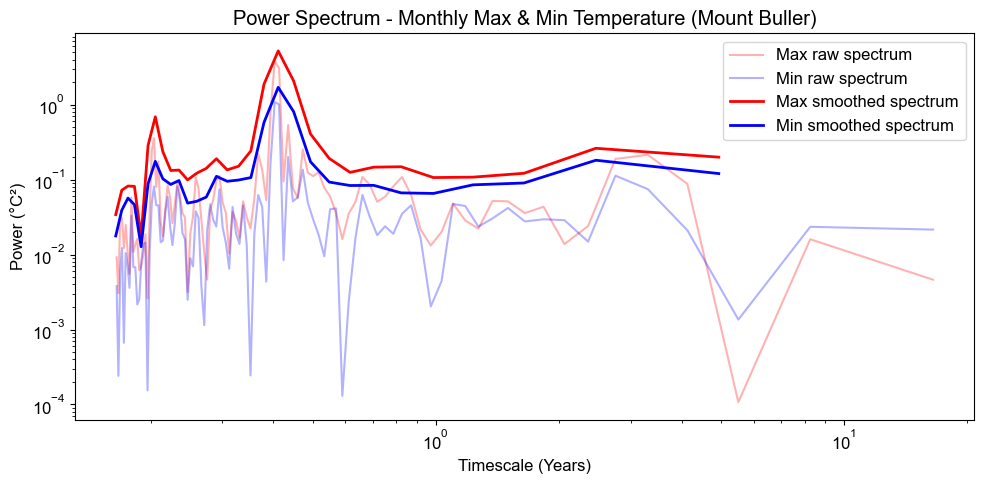

In [144]:
plt.figure(figsize=(10, 5))

plt.plot(period_max, PUU_max[1:], color='red', alpha=0.3, label='Max raw spectrum')
plt.plot(period_min, PUU_min[1:], color='blue', alpha=0.3, label='Min raw spectrum')
plt.plot(period_smooth_max, PUU_smooth_max[1:], color='red', linewidth=2, label='Max smoothed spectrum')
plt.plot(period_smooth_min, PUU_smooth_min[1:], color='blue', linewidth=2, label='Min smoothed spectrum')

plt.xlabel('Timescale (Years)')
plt.ylabel('Power (°C²)')
plt.title('Power Spectrum - Monthly Max & Min Temperature (Mount Buller)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
#plt.savefig("/Users/declanobrien/Documents/2026/PowerSpec_combined.pdf", bbox_inches="tight")
plt.show()